<a href="https://colab.research.google.com/github/princeiiitk/EDA_Titanic/blob/main/EDA_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

End to End Exploratory data Analysis (EDA) on titanic Data set

In [8]:
# IQR=Q1-Q3
# lB=Q1-1.5*IQR
# uB=Q3+1.5*IQR

**Step 1:** import important Libarary

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style(style='darkgrid')


In [10]:
!git clone 'https://github.com/HarshvardhanSingh-13/Datasets'

Cloning into 'Datasets'...
remote: Enumerating objects: 347, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 347 (delta 25), reused 0 (delta 0), pack-reused 242 (from 1)
Receiving objects: 100% (347/347), 302.89 MiB | 25.45 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (245/245), done.


Survived: The target variable (0 = No, 1 = Yes).
Pclass: Ticket class (1st, 2nd, 3rd) - acts as a proxy for socio-economic status.
Sex: Gender (male, female).
Age: Age in years (includes fractional values).
SibSp: Number of siblings/spouses aboard.
Parch: Number of parents/children aboard.
Ticket: Ticket number.
Fare: Passenger fare (in British pounds).
Cabin: Cabin number.
Embarked: Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

**Step 2 :** Loading Dataset

In [11]:
df=pd.read_csv('/content/Datasets/Titanic_Dataset/Titanic-Dataset.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


there are 891 row and 11 columns and some of value are missing like age ,Cabin, emarked

In [13]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Insights:** About 38% of passenger in this dataset survived

age : age range from 5 month to 80 year with avg age 30

Fare the fare highly with mean of 32

In [14]:
df.shape

(891, 12)

In [15]:
df['Cabin'].value_counts()

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


In [16]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


**Step 3** :   Data Cleaning

**Numerical data :** for skewdistribution like age anf fare using median is more robust than mean bcz it is not affacted bu outlier

**Categorical Data :** A common stretege is fill with the mode

**High Carinality /Too many missing value**: for col. like Cabin



In [17]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [18]:
# handle age missing
df['Age'].median()

28.0

In [19]:
df['Age']=df['Age'].fillna(df['Age'].median())
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [20]:
# handle missing value of 'Embarked'
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [21]:
# handle missing value Cabin
df['has_cabin']=df['Cabin'].notna().astype(int)
# df['has_cabin'].value_counts()
df.drop(['Cabin'],axis=1,inplace=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,has_cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [22]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Step 4: Univariate analysis
we analyze each variable individually understand

analysis categorical features


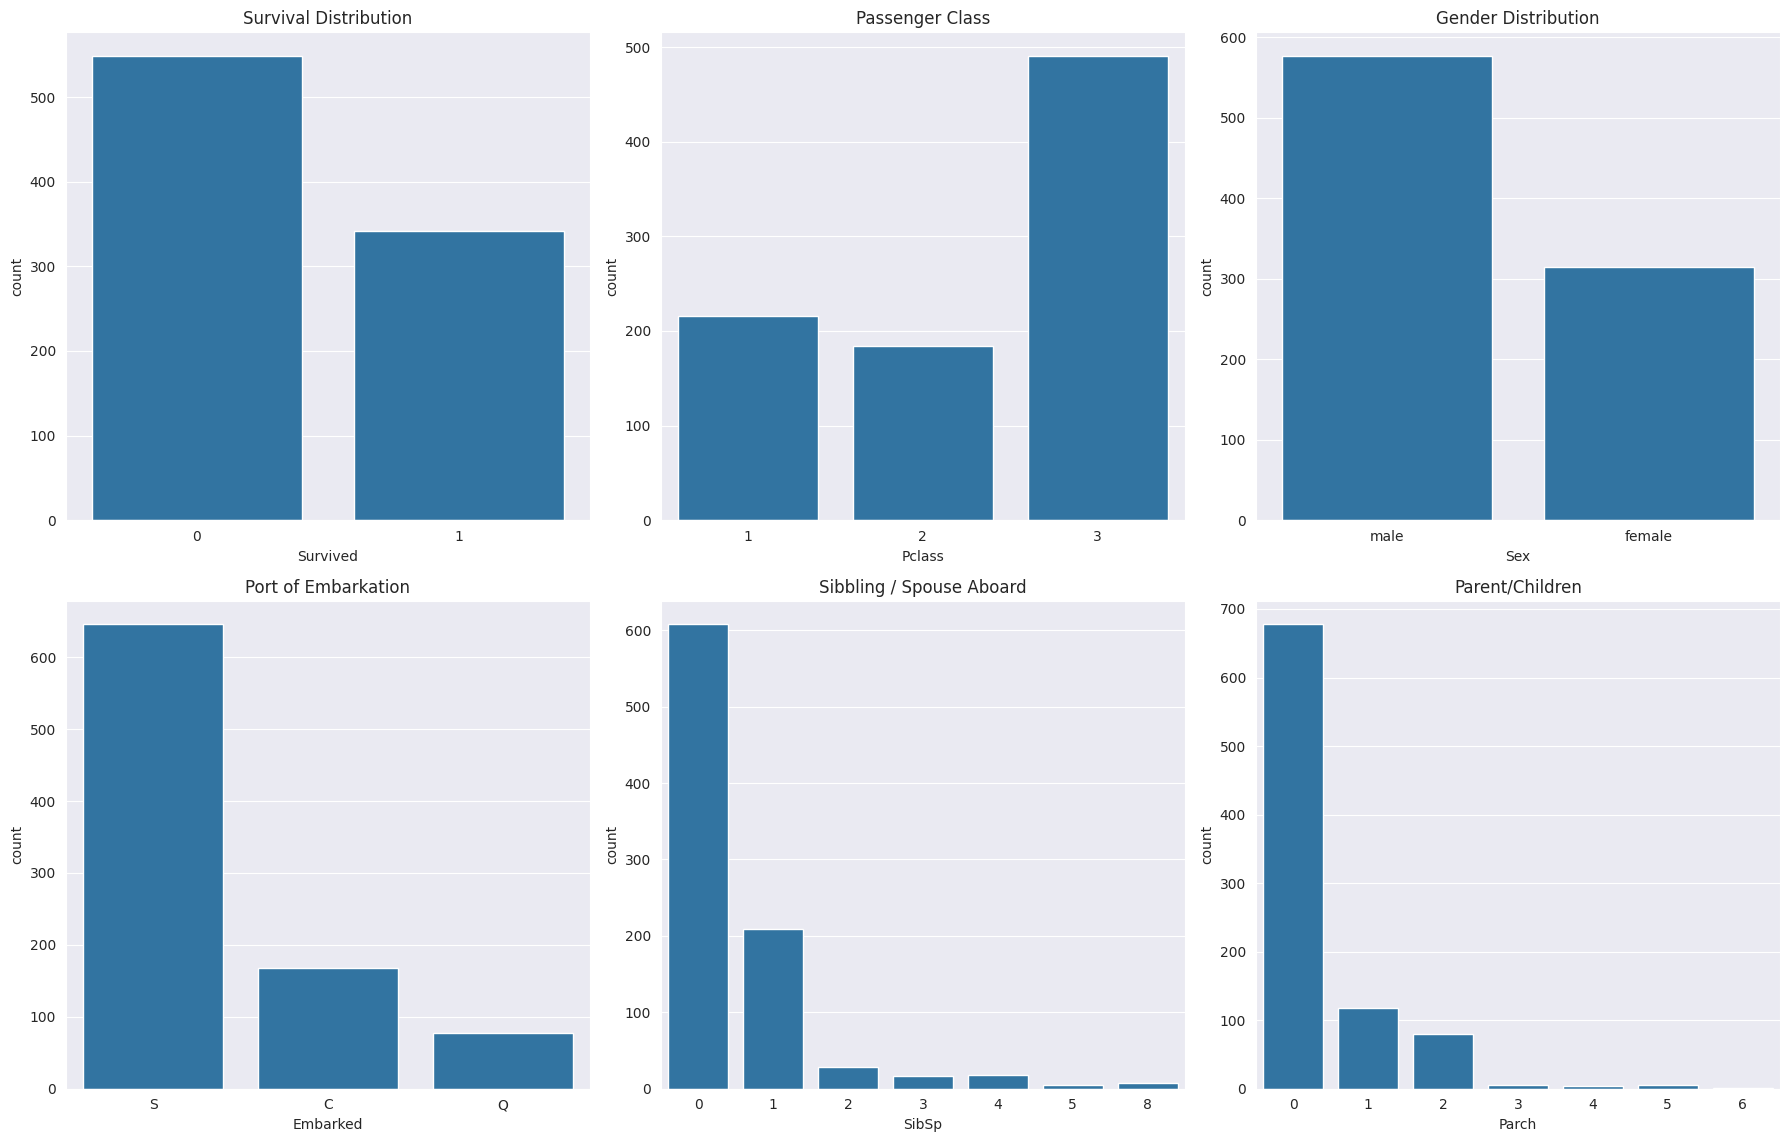

In [23]:
print("analysis categorical features")
fig,axes =plt.subplots(2,3,figsize=(18,12))
sns.countplot(ax=axes[0,0],x='Survived',data=df).set_title("Survival Distribution")
sns.countplot(ax=axes[0,1],x='Pclass',data=df).set_title("Passenger Class")
sns.countplot(ax=axes[0,2],x='Sex',data=df).set_title("Gender Distribution")
sns.countplot(ax=axes[1,0],x='Embarked',data=df).set_title("Port of Embarkation")
sns.countplot(ax=axes[1,1],x='SibSp',data=df).set_title("Sibbling / Spouse Aboard")
sns.countplot(ax=axes[1,2],x='Parch',data=df).set_title("Parent/Children")
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

Insights:

Survived :Most passenger(over 500) did not survived

pclass 3rd class was most populated followed by 1st and the 2bd

sex : there were significantly more males than female

Emarked the vast majority of passenger emarked from southampton



analysis numerical features


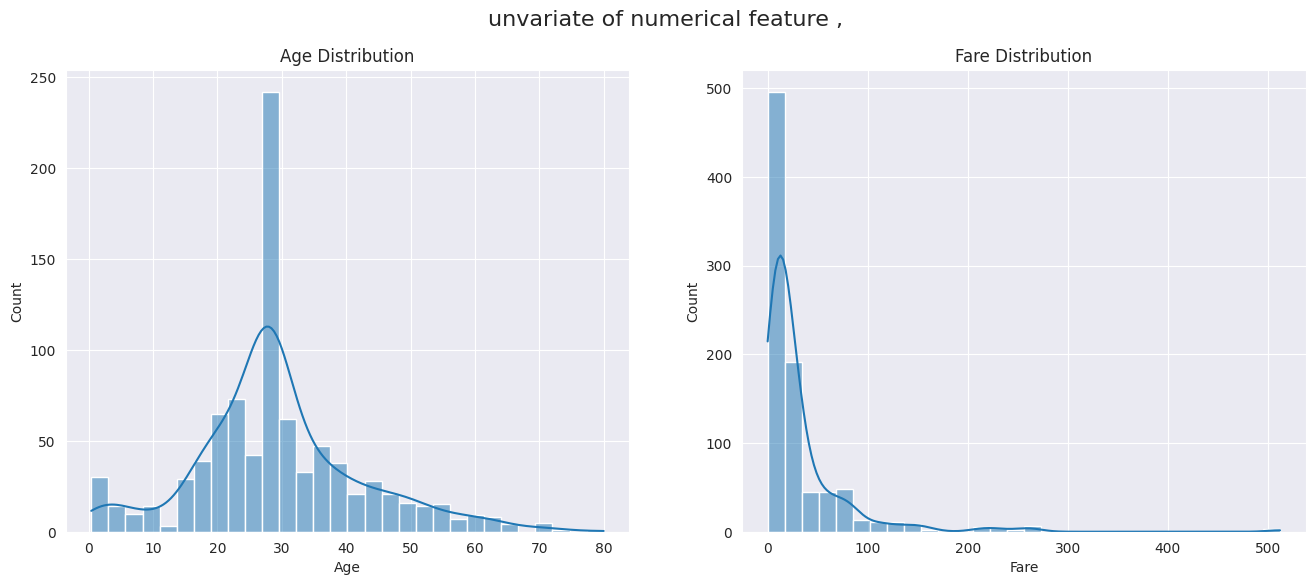

In [24]:
print("analysis numerical features")
fig ,axes =plt.subplots(1,2,figsize=(16,6))
fig.suptitle("unvariate of numerical feature ,", fontsize=16)
# "plotting age distribution"
sns.histplot(ax=axes[0],data=df,x="Age",kde=True,bins=30).set_title("Age Distribution")
sns.histplot(ax=axes[1],data=df,x="Fare",kde=True,bins=30).set_title("Fare Distribution")
plt.show()

Insights:

Age: distribution peake around the 20-30 age range . Remember we filled values with median

Fare : distribution is heavily right-skewed sonfirming that most ticket were heap with few vry expensive

 Bivariate Analysis:

bivariate analysis


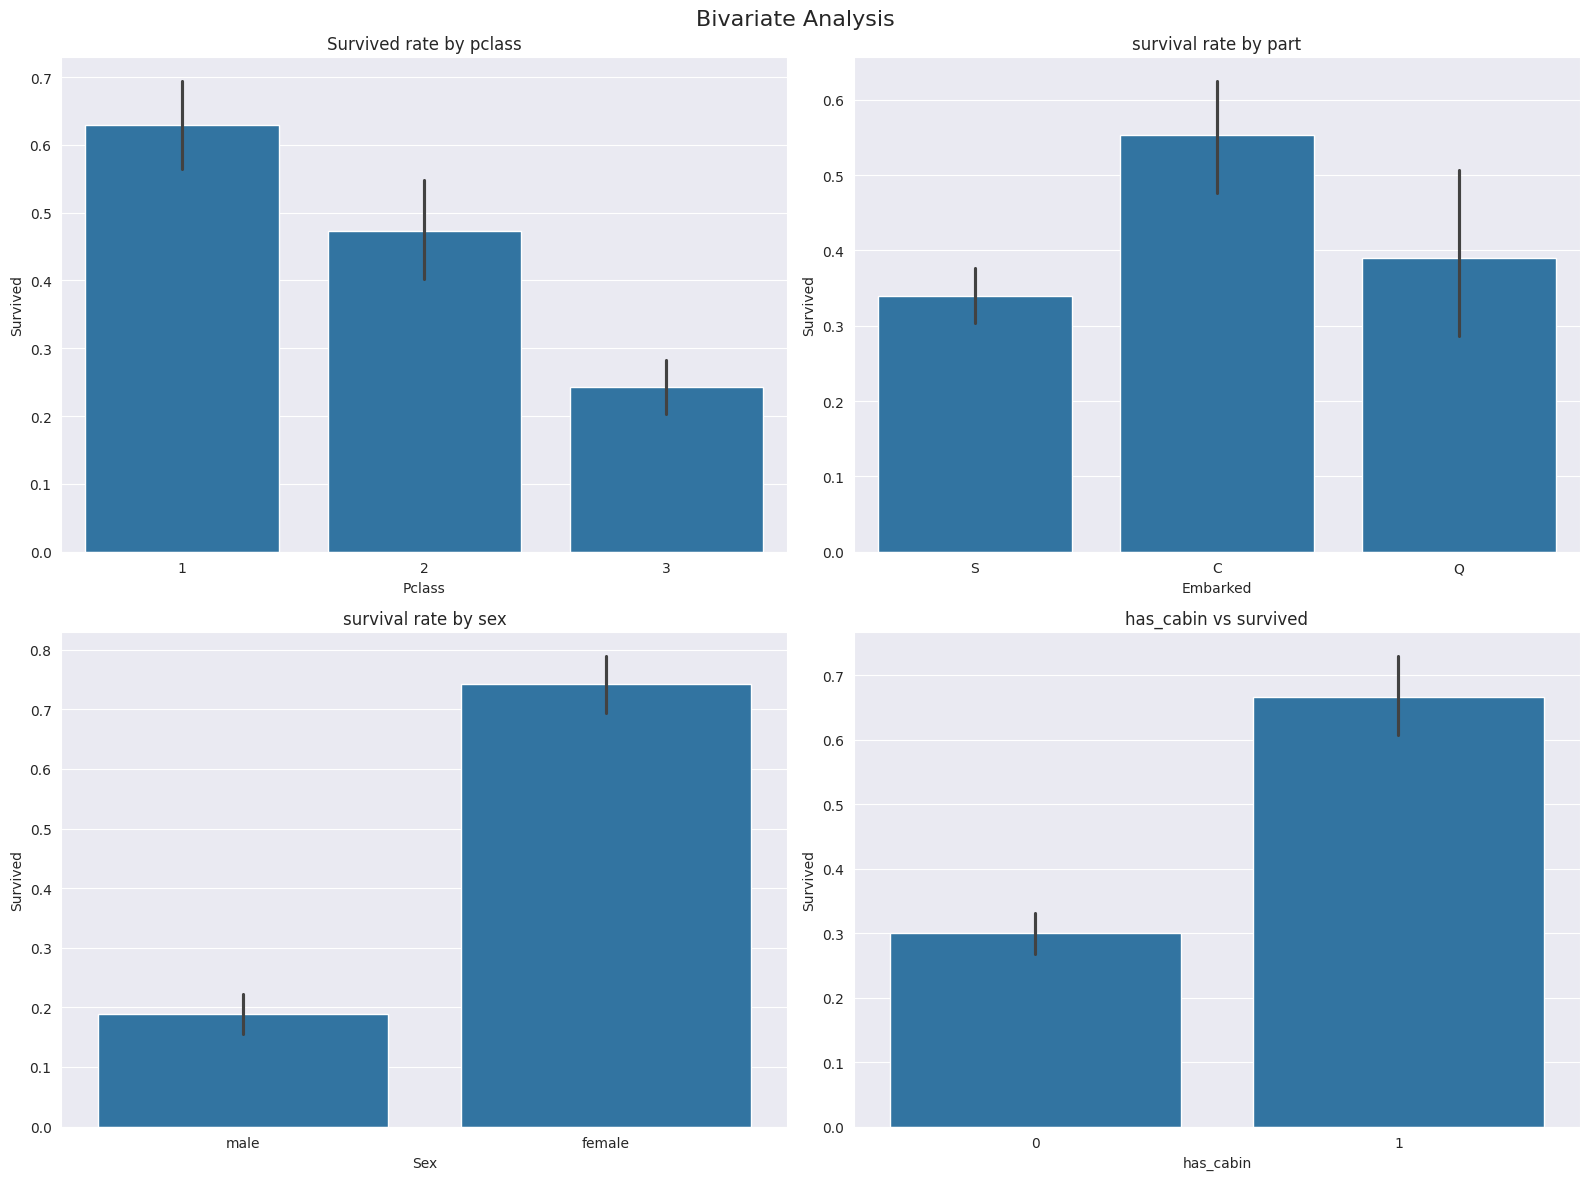

In [25]:
print("bivariate analysis")
fig, axes =plt.subplots(2,2,figsize=(16,12))

fig.suptitle("Bivariate Analysis",fontsize=16)

#pclass vs survived
sns.barplot(ax=axes[0,0],x='Pclass',y='Survived',data=df).set_title("Survived rate by pclass")

#Embarked vs Survived
sns.barplot(ax=axes[0,1],x='Embarked',y='Survived',data=df).set_title("survival rate by part")

# sex vs survived
sns.barplot(ax=axes[1,0],x='Sex',y='Survived',data=df).set_title("survival rate by sex")

# has_Cabin vs survived
sns.barplot(ax=axes[1,1],x='has_cabin',y='Survived',data=df).set_title("has_cabin vs survived")

plt.tight_layout()
plt.show()

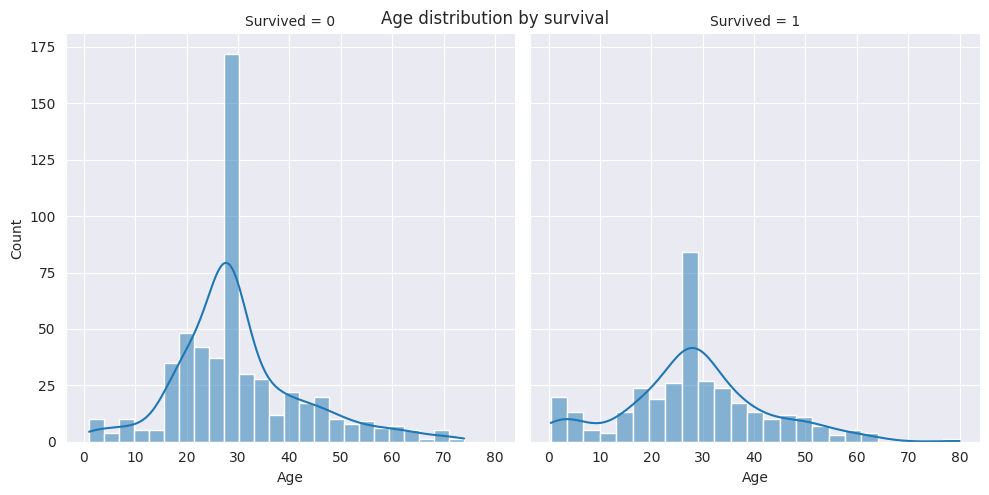

In [26]:
# Age vs survived
g=sns.FacetGrid(df,col='Survived',height=5)
g.map(sns.histplot,'Age',bins=25,kde=True)
plt.suptitle("Age distribution by survival")
plt.show()

Outlier Analysis

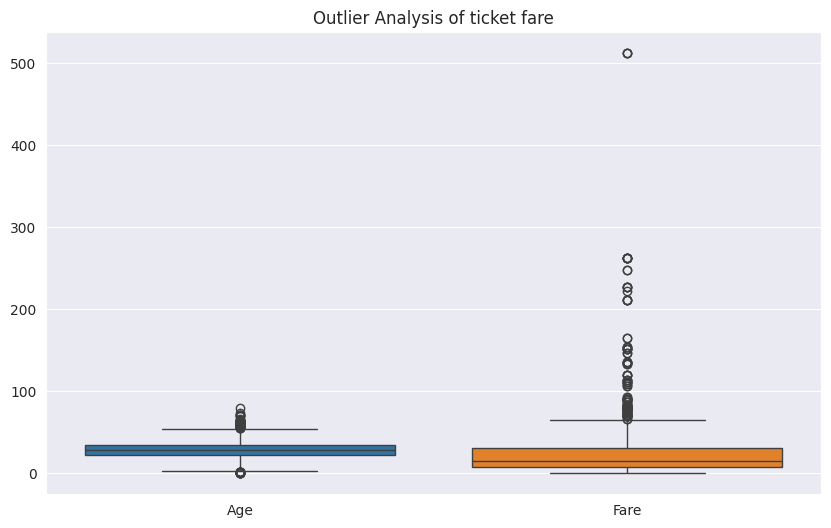

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Age','Fare']])
plt.title("Outlier Analysis of ticket fare")
plt.show()